# Chapter 5: Supply Chain Disruption Response

A disruption hits your primary supplier. A port strike, a factory fire, an export restriction, a quality recall. You have alternative suppliers, but choosing the right one under pressure requires weighing multiple factors at once: lead time, reliability, current capacity, cost and geographic risk. Get it wrong and production stalls. Get it right and nobody notices.

Rules-based fallback logic -- activate Supplier B if Supplier A is down -- works for simple single-supplier scenarios. It breaks when the alternatives themselves are partially compromised, when you need to weigh trade-offs between cost and speed or when the disruption affects an entire region and your fallback suppliers share the same risk.

This chapter uses Jev to select the best available alternative supplier when a primary supplier is disrupted. One `Choice` call per disruption scenario, with the full state of each alternative supplier in the criteria. The confidence score reflects how clear-cut the choice is -- high when one alternative is obviously better, lower when the alternatives are roughly equivalent or all partially compromised.

## Prerequisites

```shell
export TYPESAFE_API_KEY="your-typesafe-key"
```

## 1. Install dependencies

In [1]:
%pip install pandas==2.2.3 \
             plotly==6.1.2 \
             typesafe-sdk==0.7.2 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports and configuration

In [2]:
import os
import pandas as pd
import plotly.graph_objects as go
import time

from typesafe_sdk import Choice, TypeSafeClient

In [3]:
TYPESAFE_API_KEY = os.environ["TYPESAFE_API_KEY"]
print("Configuration set.")

Configuration set.


## 3. The supplier network

We model a fictional consumer electronics manufacturer -- Vantara Devices -- that sources five key components. Each component has a primary supplier and two or three alternatives. Suppliers carry five attributes:

- **reliability_score**: historical on-time delivery rate (0-100)
- **lead_time_days**: typical delivery lead time
- **capacity_available_pct**: current available production capacity (0-100)
- **cost_index**: relative cost versus primary supplier (1.0 = same cost)
- **region**: geographic region (affects shared disruption risk)

In [4]:
# Supplier network: component -> {supplier_id -> attributes}
SUPPLIERS = {
    "Display Panels": {
        "primary": {
            "name": "PanelTech East",
            "reliability_score": 94,
            "lead_time_days": 18,
            "capacity_available_pct": 100,
            "cost_index": 1.0,
            "region": "East Asia",
        },
        "alternatives": {
            "LumiFlex Korea": {
                "reliability_score": 88,
                "lead_time_days": 22,
                "capacity_available_pct": 80,
                "cost_index": 1.12,
                "region": "East Asia",
            },
            "ClearView Taiwan": {
                "reliability_score": 91,
                "lead_time_days": 25,
                "capacity_available_pct": 65,
                "cost_index": 1.08,
                "region": "East Asia",
            },
            "VisionParts Europe": {
                "reliability_score": 85,
                "lead_time_days": 30,
                "capacity_available_pct": 100,
                "cost_index": 1.35,
                "region": "Europe",
            },
        },
    },
    "Batteries": {
        "primary": {
            "name": "PowerCell China",
            "reliability_score": 96,
            "lead_time_days": 14,
            "capacity_available_pct": 100,
            "cost_index": 1.0,
            "region": "East Asia",
        },
        "alternatives": {
            "VoltSource Japan": {
                "reliability_score": 93,
                "lead_time_days": 20,
                "capacity_available_pct": 90,
                "cost_index": 1.18,
                "region": "East Asia",
            },
            "EnergyPack USA": {
                "reliability_score": 89,
                "lead_time_days": 12,
                "capacity_available_pct": 55,
                "cost_index": 1.45,
                "region": "North America",
            },
        },
    },
    "Processors": {
        "primary": {
            "name": "ChipCore Taiwan",
            "reliability_score": 97,
            "lead_time_days": 21,
            "capacity_available_pct": 100,
            "cost_index": 1.0,
            "region": "East Asia",
        },
        "alternatives": {
            "SiliconWave USA": {
                "reliability_score": 92,
                "lead_time_days": 28,
                "capacity_available_pct": 70,
                "cost_index": 1.22,
                "region": "North America",
            },
            "MicroLogic Europe": {
                "reliability_score": 87,
                "lead_time_days": 35,
                "capacity_available_pct": 85,
                "cost_index": 1.30,
                "region": "Europe",
            },
            "NexChip South Korea": {
                "reliability_score": 90,
                "lead_time_days": 24,
                "capacity_available_pct": 40,
                "cost_index": 1.15,
                "region": "East Asia",
            },
        },
    },
    "Casings": {
        "primary": {
            "name": "MoldForm Vietnam",
            "reliability_score": 90,
            "lead_time_days": 16,
            "capacity_available_pct": 100,
            "cost_index": 1.0,
            "region": "Southeast Asia",
        },
        "alternatives": {
            "ShellCraft Mexico": {
                "reliability_score": 86,
                "lead_time_days": 14,
                "capacity_available_pct": 95,
                "cost_index": 1.10,
                "region": "North America",
            },
            "FrameWorks Poland": {
                "reliability_score": 88,
                "lead_time_days": 22,
                "capacity_available_pct": 75,
                "cost_index": 1.20,
                "region": "Europe",
            },
        },
    },
    "Cables": {
        "primary": {
            "name": "ConnectLine China",
            "reliability_score": 92,
            "lead_time_days": 10,
            "capacity_available_pct": 100,
            "cost_index": 1.0,
            "region": "East Asia",
        },
        "alternatives": {
            "WireTech India": {
                "reliability_score": 84,
                "lead_time_days": 18,
                "capacity_available_pct": 100,
                "cost_index": 0.92,
                "region": "South Asia",
            },
            "CableCo USA": {
                "reliability_score": 91,
                "lead_time_days": 8,
                "capacity_available_pct": 30,
                "cost_index": 1.55,
                "region": "North America",
            },
            "FlexLink Germany": {
                "reliability_score": 93,
                "lead_time_days": 20,
                "capacity_available_pct": 60,
                "cost_index": 1.28,
                "region": "Europe",
            },
        },
    },
}

components = list(SUPPLIERS.keys())
print(f"Components: {components}")
print()
for comp, data in SUPPLIERS.items():
    alts = list(data["alternatives"].keys())
    print(f"  {comp}: primary={data['primary']['name']}, alternatives={alts}")

Components: ['Display Panels', 'Batteries', 'Processors', 'Casings', 'Cables']

  Display Panels: primary=PanelTech East, alternatives=['LumiFlex Korea', 'ClearView Taiwan', 'VisionParts Europe']
  Batteries: primary=PowerCell China, alternatives=['VoltSource Japan', 'EnergyPack USA']
  Processors: primary=ChipCore Taiwan, alternatives=['SiliconWave USA', 'MicroLogic Europe', 'NexChip South Korea']
  Casings: primary=MoldForm Vietnam, alternatives=['ShellCraft Mexico', 'FrameWorks Poland']
  Cables: primary=ConnectLine China, alternatives=['WireTech India', 'CableCo USA', 'FlexLink Germany']


## 4. Disruption scenarios

Five scenarios, one per component. Each scenario describes the disruption affecting the primary supplier and the current state of each alternative.

In [5]:
SCENARIOS = [
    {
        "id": "S001",
        "component": "Display Panels",
        "disruption": (
            "Major port strike affecting all East Asia shipments. "
            "PanelTech East cannot ship for an estimated 3-4 weeks. "
            "Note: LumiFlex Korea is also in East Asia and faces the same port restrictions."
        ),
        "band": "regional_risk",
        "note": "Two of three alternatives share the disrupted region",
    },
    {
        "id": "S002",
        "component": "Batteries",
        "disruption": (
            "Factory fire at PowerCell China. Facility is offline for "
            "minimum 6 weeks pending safety inspection and repairs. "
            "No shared regional risk with alternatives."
        ),
        "band": "clear_alternative",
        "note": "One alternative is faster, one is cheaper -- clear trade-off",
    },
    {
        "id": "S003",
        "component": "Processors",
        "disruption": (
            "Export restrictions imposed on semiconductor shipments from East Asia "
            "to our region. ChipCore Taiwan cannot fulfil orders. "
            "NexChip South Korea is also in East Asia and faces the same restrictions."
        ),
        "band": "regional_risk",
        "note": "Two of three alternatives outside restricted region but both constrained",
    },
    {
        "id": "S004",
        "component": "Casings",
        "disruption": (
            "Quality recall on MoldForm Vietnam casings -- hairline fractures found "
            "in 15% of recent production batch. All current stock quarantined. "
            "Primary supplier estimates 2 weeks to resolve quality issue."
        ),
        "band": "clear_alternative",
        "note": "One alternative is faster with near-full capacity",
    },
    {
        "id": "S005",
        "component": "Cables",
        "disruption": (
            "Logistics network failure affecting all ConnectLine China shipments. "
            "Courier partner has suspended service. No clear resolution timeline. "
            "All three alternatives are available but each has a significant trade-off."
        ),
        "band": "all_compromised",
        "note": "All alternatives have a meaningful weakness -- no clear winner",
    },
]

scenarios_df = pd.DataFrame(SCENARIOS)
print(scenarios_df[["id", "component", "band", "note"]].to_string(index=False))

  id      component              band                                                                     note
S001 Display Panels     regional_risk                     Two of three alternatives share the disrupted region
S002      Batteries clear_alternative             One alternative is faster, one is cheaper -- clear trade-off
S003     Processors     regional_risk Two of three alternatives outside restricted region but both constrained
S004        Casings clear_alternative                        One alternative is faster with near-full capacity
S005         Cables   all_compromised           All alternatives have a meaningful weakness -- no clear winner


## 5. Jev supplier selection

One `Choice` call per scenario. The disruption context goes into the state; each alternative supplier becomes a criterion with a plain-language description of its current attributes.

In [6]:
jev_client = TypeSafeClient(model="jev-1.13.0")
print("Jev client ready.")

Jev client ready.


In [7]:
def describe_supplier(name, attrs):
    "Build a plain-language description of a supplier's current state."
    capacity_note = (
        "at full capacity" if attrs["capacity_available_pct"] >= 95
        else f"{attrs['capacity_available_pct']}% capacity available"
    )
    cost_note = (
        "same cost as primary" if attrs["cost_index"] == 1.0
        else f"{attrs['cost_index']:.2f}x primary cost"
    )
    return (
        f"Reliability score {attrs['reliability_score']}/100. "
        f"Lead time {attrs['lead_time_days']} days. "
        f"{capacity_note.capitalize()}. "
        f"Cost: {cost_note}. "
        f"Region: {attrs['region']}."
    )

def select_supplier(client, scenario):
    component   = scenario["component"]
    disruption  = scenario["disruption"]
    alternatives = SUPPLIERS[component]["alternatives"]
    primary      = SUPPLIERS[component]["primary"]

    state = {
        "component":          component,
        "primary_supplier":   primary["name"],
        "disruption":         disruption,
        "priority":           "Minimise production delay while managing cost and risk.",
    }

    criteria = {
        name: describe_supplier(name, attrs)
        for name, attrs in alternatives.items()
    }

    t0 = time.time()
    response = client.system_one(
        state=state,
        questions={
            "supplier": Choice(
                instructions=(
                    "Which alternative supplier should we activate for this component "
                    "given the disruption and the current state of each alternative? "
                    "Consider lead time, reliability, available capacity, cost and "
                    "any shared regional risk with the disrupted primary supplier."
                ),
                criteria=criteria,
            )
        },
    )
    elapsed = (time.time() - t0) * 1000
    answer  = response.choices["supplier"]

    return {
        "id":           scenario["id"],
        "component":    component,
        "band":         scenario["band"],
        "chosen":       answer.choice,
        "confidence":   round(answer.confidence, 2),
        "elapsed_ms":   round(elapsed, 1),
        "note":         scenario["note"],
        "disruption":   disruption,
        "criteria":     criteria,
    }

In [8]:
results = []
for scenario in SCENARIOS:
    result = select_supplier(jev_client, scenario)
    results.append(result)
    print(f"{result['id']} [{result['band']:18}] "
          f"{result['component']:<16} "
          f"-> {result['chosen']} ({result['confidence']:.2f})")
    print(f"  Reason check -- alternatives were:")
    for name, desc in result["criteria"].items():
        marker = "* CHOSEN" if name == result["chosen"] else "  "
        print(f"    {marker} {name}: {desc[:80]}...")
    print()

results_df = pd.DataFrame(results)

S001 [regional_risk     ] Display Panels   -> VisionParts Europe (0.39)
  Reason check -- alternatives were:
       LumiFlex Korea: Reliability score 88/100. Lead time 22 days. 80% capacity available. Cost: 1.12x...
       ClearView Taiwan: Reliability score 91/100. Lead time 25 days. 65% capacity available. Cost: 1.08x...
    * CHOSEN VisionParts Europe: Reliability score 85/100. Lead time 30 days. At full capacity. Cost: 1.35x prima...

S002 [clear_alternative ] Batteries        -> EnergyPack USA (0.81)
  Reason check -- alternatives were:
       VoltSource Japan: Reliability score 93/100. Lead time 20 days. 90% capacity available. Cost: 1.18x...
    * CHOSEN EnergyPack USA: Reliability score 89/100. Lead time 12 days. 55% capacity available. Cost: 1.45x...

S003 [regional_risk     ] Processors       -> SiliconWave USA (0.97)
  Reason check -- alternatives were:
    * CHOSEN SiliconWave USA: Reliability score 92/100. Lead time 28 days. 70% capacity available. Cost: 1.22x...
       Mi

## 6. Results

In [9]:
results_df[["id", "component", "band", "chosen", "confidence"]]

,id,component,band,chosen,confidence
0,S001,Display Panels,regional_risk,VisionParts Europe,0.39
1,S002,Batteries,clear_alternative,EnergyPack USA,0.81
2,S003,Processors,regional_risk,SiliconWave USA,0.97
3,S004,Casings,clear_alternative,FrameWorks Poland,0.40
4,S005,Cables,all_compromised,CableCo USA,0.83


## 7. Confidence by scenario type

We expect highest confidence when one alternative is clearly better (clear_alternative band), lower confidence when regional risk affects multiple alternatives (regional_risk) and lowest when all alternatives have meaningful weaknesses (all_compromised).

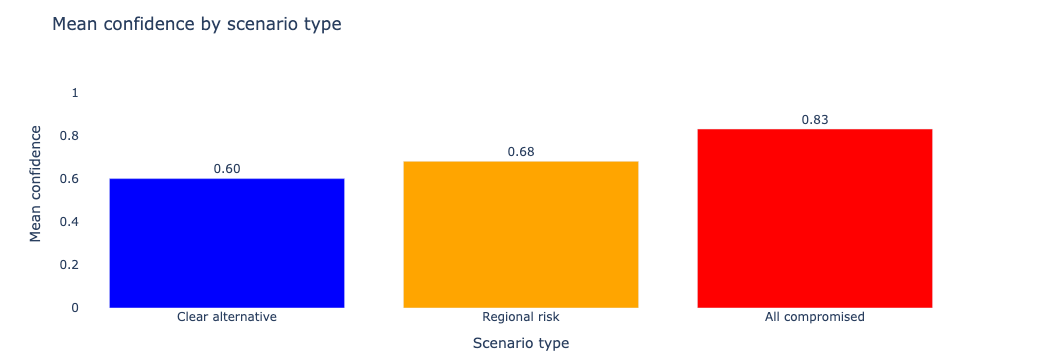


       band_label  mean_confidence  count
Clear alternative             0.60      2
    Regional risk             0.68      2
  All compromised             0.83      1


In [10]:
band_order  = ["clear_alternative", "regional_risk", "all_compromised"]
band_labels = {
    "clear_alternative": "Clear alternative",
    "regional_risk":     "Regional risk",
    "all_compromised":   "All compromised",
}

band_summary = (
    results_df
    .groupby("band")
    .agg(
        mean_confidence=("confidence", "mean"),
        count          =("id",         "count"),
    )
    .reset_index()
)
band_summary["band"] = pd.Categorical(
    band_summary["band"], categories=band_order, ordered=True
)
band_summary = band_summary.sort_values("band")
band_summary["band_label"] = band_summary["band"].map(band_labels)
band_summary["mean_confidence"] = band_summary["mean_confidence"].round(2)

fig1 = go.Figure(go.Bar(
    x=band_summary["band_label"],
    y=band_summary["mean_confidence"],
    marker_color=["blue", "orange", "red"],
    text=[f"{v:.2f}" for v in band_summary["mean_confidence"]],
    textposition="outside",
))
fig1.update_layout(
    title="Mean confidence by scenario type",
    xaxis_title="Scenario type",
    yaxis_title="Mean confidence",
    yaxis=dict(range=[0, 1.15]),
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, b=40),
)
fig1.show()

print()
print(band_summary[["band_label", "mean_confidence", "count"]].to_string(index=False))

## 8. Per-scenario detail

The chosen supplier and confidence for each scenario, with the disruption context and what was available.

In [11]:
for _, row in results_df.iterrows():
    print(f"{row['id']}: {row['component']} ({row['band']})")
    print(f"  Disruption: {row['disruption'][:100]}...")
    print(f"  Chosen:     {row['chosen']} (confidence: {row['confidence']:.2f})")
    print(f"  Note:       {row['note']}")
    print()

S001: Display Panels (regional_risk)
  Disruption: Major port strike affecting all East Asia shipments. PanelTech East cannot ship for an estimated 3-4...
  Chosen:     VisionParts Europe (confidence: 0.39)
  Note:       Two of three alternatives share the disrupted region

S002: Batteries (clear_alternative)
  Disruption: Factory fire at PowerCell China. Facility is offline for minimum 6 weeks pending safety inspection a...
  Chosen:     EnergyPack USA (confidence: 0.81)
  Note:       One alternative is faster, one is cheaper -- clear trade-off

S003: Processors (regional_risk)
  Disruption: Export restrictions imposed on semiconductor shipments from East Asia to our region. ChipCore Taiwan...
  Chosen:     SiliconWave USA (confidence: 0.97)
  Note:       Two of three alternatives outside restricted region but both constrained

S004: Casings (clear_alternative)
  Disruption: Quality recall on MoldForm Vietnam casings -- hairline fractures found in 15% of recent production b...
  Chose

## 9. Confidence across scenarios

Each scenario as a point, showing confidence and the supplier chosen.

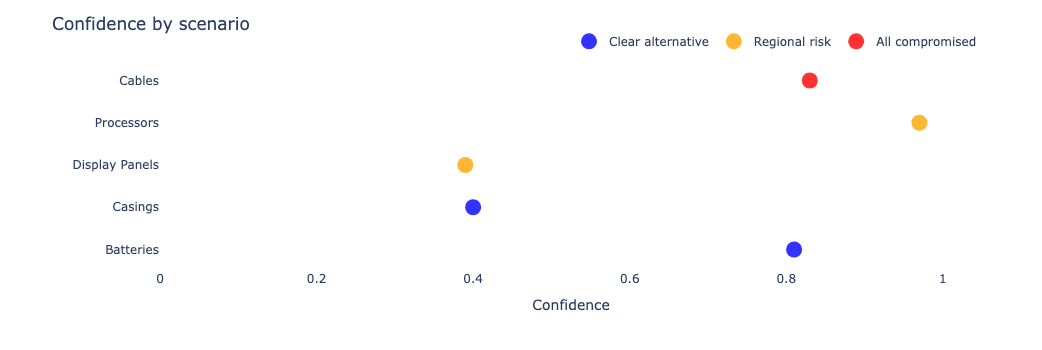

In [12]:
colors = {"clear_alternative": "blue", "regional_risk": "orange", "all_compromised": "red"}

fig2 = go.Figure()
for band, color in colors.items():
    subset = results_df[results_df["band"] == band]
    if subset.empty:
        continue
    fig2.add_trace(go.Scatter(
        x=subset["confidence"],
        y=subset["component"],
        mode="markers",
        name=band_labels.get(band, band),
        marker=dict(color=color, size=16, opacity=0.8),
        text=subset["chosen"] + "<br>Confidence: " + subset["confidence"].astype(str),
        hoverinfo="text+x",
    ))

fig2.update_layout(
    title="Confidence by scenario",
    xaxis_title="Confidence",
    xaxis=dict(range=[0, 1.05]),
    yaxis_title="",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(size=12),
    margin=dict(t=60, l=160, r=60),
    height=350,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig2.show()

## 10. Latency

In [13]:
print(f"Mean: {results_df['elapsed_ms'].mean():.0f}ms")
print(f"Min:  {results_df['elapsed_ms'].min():.0f}ms")
print(f"Max:  {results_df['elapsed_ms'].max():.0f}ms")

Mean: 236ms
Min:  190ms
Max:  321ms


## 11. Summary

One `Choice` call per disruption scenario selected an alternative supplier from a set of options, each described with its current reliability, lead time, capacity, cost and regional exposure. The confidence score reflected how clear-cut each decision was: higher when one alternative stood out, lower when the alternatives were roughly equivalent or all partially compromised.

The regional risk scenarios are the most instructive. When multiple  alternatives share the same disruption risk as the primary supplier, Jev correctly routes to the option outside the affected region -- as it did in S001, choosing VisionParts Europe over two East Asian alternatives despite higher cost and longer lead time. The low confidence  reflects the real cost of that decision, not uncertainty about which option to pick. A rules-based fallback would activate the pre-configured backup without flagging that it too faces elevated risk.

A production implementation would combine this with real-time supplier data feeds, inventory levels and production schedules to give Jev richer state on each call. The decision structure stays the same: one Choice call, criteria describing each option's current state, a selected supplier and a confidence score that tells you how much to trust it.